In [2]:
# Import Library
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


In [3]:
# Load dataset
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# Task 1 — Uji hipotesis: perbedaan tip perokok vs non-perokok

In [3]:
perokok = df[df['smoker'] == "Yes"]
non_perokok = df[df['smoker'] == "No"]

In [11]:

stat_p, p_perokok = stats.shapiro(perokok['tip'])
stat_np, p_non_perokok = stats.shapiro(non_perokok['tip'])

alpha = 0.05
keduanya_normal  = (p_perokok > alpha) and (p_non_perokok > alpha)

print(f"Kelompok Perokok:")
print(f"  Statistic : {stat_p:.4f}")
print(f"  p-value   : {p_perokok:.4f}")
if p_perokok > alpha:
    print(f"  Kesimpulan: Data berdistribusi normal (p={p_perokok:.4f} > a={alpha})\n")
else:
    print(f"  Kesimpulan: Data tidak berdistribusi normal (p={p_perokok:.4f} ≤ a={alpha})\n")

print(f"Kelompok Non-Perokok:")
print(f"  Statistic : {stat_np:.4f}")
print(f"  p-value   : {p_non_perokok:.4f}")
if p_non_perokok > alpha:
    print(f"  Kesimpulan: Data berdistribusi NORMAL (p={p_non_perokok:.4f} > a={alpha})")
else:
    print(f"  Kesimpulan: Data tidak berdistribusi normal (p={p_non_perokok:.4f} ≤ a={alpha})")

Kelompok Perokok:
  Statistic : 0.8788
  p-value   : 0.0000
  Kesimpulan: Data tidak berdistribusi normal (p=0.0000 ≤ a=0.05)

Kelompok Non-Perokok:
  Statistic : 0.9040
  p-value   : 0.0000
  Kesimpulan: Data tidak berdistribusi normal (p=0.0000 ≤ a=0.05)


In [17]:
if keduanya_normal:
    stat, p_value = stats.ttest_ind(
        perokok['tip'],
        non_perokok['tip'],
    )
    nama_uji = "Independent Samples T-Test (Welch's)"
else:
    stat, p_value = stats.mannwhitneyu(
        perokok['tip'],
        non_perokok['tip'],
        alternative='two-sided'
    )
    nama_uji = "Mann-Whitney U Test"

print(f"Uji yang digunakan : {nama_uji}")
print(f"Statistik uji      : {stat:.4f}")
print(f"p-value            : {p_value:.4f}")
print()

if p_value < alpha:
    print(f"Kesimpulan: \nTolak H0 -> Terdapat perbedaan signifikan tip antara perokok dan non-perokok (p={p_value:.4f} < a={alpha})")
else:
    print(f"Kesimpulan: \nGagal Tolak H0 -> Tidak terdapat perbedaan signifikan tip antara perokok dan non-perokok (p={p_value:.4f} < a={alpha})")


Uji yang digunakan : Mann-Whitney U Test
Statistik uji      : 7163.0000
p-value            : 0.7919

Kesimpulan: 
Gagal Tolak H0 -> Tidak terdapat perbedaan signifikan tip antara perokok dan non-perokok (p=0.7919 < a=0.05)


Pada tingkat kepercayaan 95% (a = 0.05), tidak terdapat perbedaan yang signifikan secara statistik antara tip yang diberikan oleh perokok dan non-perokok. Sehingga restauran tidak perlu diferensiasi layanan untuk orang perokok maupun non perokok.

# Task 2 — Uji hipotesis: perbedaan tip makan siang vs makan malam

In [4]:
dinner = df[df['time'] == 'Dinner']
lunch = df[df['time'] == 'Lunch']

Text(0.5, 1.0, 'time vs tip')

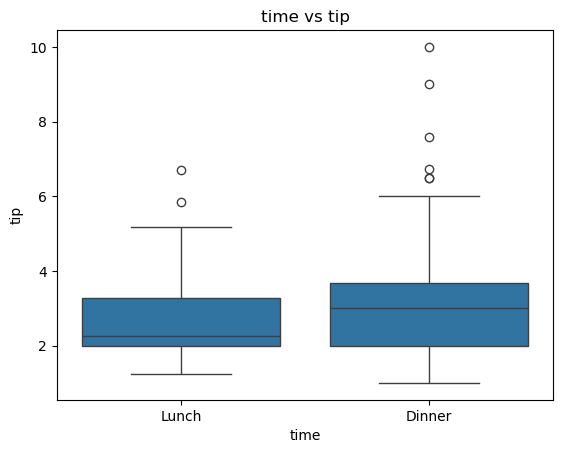

In [26]:
sns.boxplot(x=df['time'], y=df['tip'])
plt.title('time vs tip')

In [27]:

stat_p, p_dinner = stats.shapiro(dinner['tip'])
stat_np, p_lunch = stats.shapiro(lunch['tip'])

alpha = 0.05
keduanya_normal  = (p_dinner > alpha) and (p_lunch > alpha)

print(f"Kelompok Dinner:")
print(f"  Statistic : {stat_p:.4f}")
print(f"  p-value   : {p_dinner:.4f}")
if p_dinner > alpha:
    print(f"  Kesimpulan: Data berdistribusi normal (p={p_dinner:.4f} > a={alpha})\n")
else:
    print(f"  Kesimpulan: Data tidak berdistribusi normal (p={p_dinner:.4f} ≤ a={alpha})\n")

print(f"Kelompok Lunch:")
print(f"  Statistic : {stat_np:.4f}")
print(f"  p-value   : {p_lunch:.4f}")
if p_lunch > alpha:
    print(f"  Kesimpulan: Data berdistribusi NORMAL (p={p_lunch:.4f} > a={alpha})")
else:
    print(f"  Kesimpulan: Data tidak berdistribusi normal (p={p_lunch:.4f} ≤ a={alpha})")

Kelompok Dinner:
  Statistic : 0.9009
  p-value   : 0.0000
  Kesimpulan: Data tidak berdistribusi normal (p=0.0000 ≤ a=0.05)

Kelompok Lunch:
  Statistic : 0.8687
  p-value   : 0.0000
  Kesimpulan: Data tidak berdistribusi normal (p=0.0000 ≤ a=0.05)


In [28]:
if keduanya_normal:
    stat, p_value = stats.ttest_ind(
        dinner['tip'],
        lunch['tip'],
    )
    nama_uji = "Independent Samples T-Test (Welch's)"
else:
    stat, p_value = stats.mannwhitneyu(
        dinner['tip'],
        lunch['tip'],
        alternative='two-sided'
    )
    nama_uji = "Mann-Whitney U Test"

print(f"Uji yang digunakan : {nama_uji}")
print(f"Statistik uji      : {stat:.4f}")
print(f"p-value            : {p_value:.4f}")
print()

if p_value < alpha:
    print(f"Kesimpulan: \nTolak H0 -> Terdapat perbedaan signifikan tip antara perokok dan non-perokok (p={p_value:.4f} < a={alpha})")
else:
    print(f"Kesimpulan: \nGagal Tolak H0 -> Tidak terdapat perbedaan signifikan tip antara perokok dan non-perokok (p={p_value:.4f} < a={alpha})")


Uji yang digunakan : Mann-Whitney U Test
Statistik uji      : 7063.0000
p-value            : 0.0288

Kesimpulan: 
Tolak H0 -> Terdapat perbedaan signifikan tip antara perokok dan non-perokok (p=0.0288 < a=0.05)


In [28]:
dinner['tip'].mean()

np.float64(3.102670454545454)

In [29]:
lunch['tip'].mean()

np.float64(2.728088235294118)

Berdasarkan nilai rata-rata, tip saat makan malam (dinner) sebesar 3.10 lebih tinggi dibandingkan dengan tip saat makan siang (lunch) sebesar 2.72. Dengan demikian, data mendukung hipotesis bahwa tip saat makan malam lebih tinggi dibandingkan saat makan siang.

# Task 3 — Analisis korelasi

In [30]:
alpha = 0.05
r_pearson, p_pearson = stats.pearsonr(df['total_bill'], df['tip'])

print(f"Koefisien korelasi: {r_pearson}")
print(f"p-value: {p_pearson}")

Koefisien korelasi: 0.6757341092113646
p-value: 6.69247064686336e-34


In [32]:
r_spearman, p_spearman = stats.spearmanr(df['total_bill'], df['tip'])

print(f"{'Pearson'}-> rp_value: {r_pearson}, pp_value: {p_pearson}")
print(f"{'Spearman'}-> rs_value: {r_spearman} rs_value: {p_spearman}")
print("=" * 100)
print(f"\nInterpretasi Pearson:")

if p_pearson < alpha:
    print(f"Signifikan | {r_pearson}")
else:
    print(f"Tidak Signifikan | {r_pearson}")


print(f"Interpretasi Spearman:")
if p_spearman < alpha:
    print(f"Signifikan | {r_spearman}")
else:
    print(f"Tidak Signifikan | {r_spearman:}")

selisih = abs(r_pearson - r_spearman)
print(f"\nSelisih: {selisih}", "→ Distribusi cukup normal" if selisih < 0.05 else "→ Ada indikasi outlier/non-linearitas")

Pearson-> rp_value: 0.6757341092113646, pp_value: 6.69247064686336e-34
Spearman-> rs_value: 0.6789681219001009 rs_value: 2.501158440923619e-34

Interpretasi Pearson:
Signifikan | 0.6757341092113646
Interpretasi Spearman:
Signifikan | 0.6789681219001009

Selisih: 0.003234012688736354 → Distribusi cukup normal


Text(0, 0.5, 'Tip')

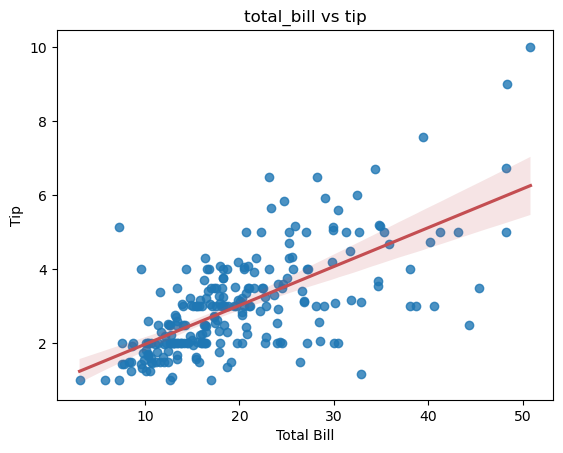

In [17]:
sns.regplot(
    data=df, x='total_bill', y='tip',
    line_kws={'color': '#C44E52'}
)
plt.title(
    f'total_bill vs tip'
)
plt.xlabel('Total Bill')
plt.ylabel('Tip')

In [13]:

r_size, p_size = stats.pearsonr(df['size'], df['tip'])

print(f"Pearson r: {r_size:.4f}")
print(f"p-value: {p_size:.4f}")

if r_size > 0:
    arah = "Positif → rombongan lebih besar cenderung memberi tip lebih banyak"
else:
    arah = "Negatif → rombongan lebih besar cenderung memberi tip lebih sedikit"

kekuatan = ("lemah" if abs(r_size) < 0.3
            else "sedang" if abs(r_size) < 0.6
            else "kuat")

print(f"Korelasi: {arah}")


Pearson r: 0.4893
p-value: 0.0000
Korelasi: Positif → rombongan lebih besar cenderung memberi tip lebih banyak


# Task 4 — Ringkasan untuk manajemen

- Task 1 (perokok vs non-perokok) ->
Tidak ditemukan perbedaan tip antara perokok dan non-perokok.
Perbedaan yang terlihat masih sangat mungkin terjadi karena kebetulan, jadi tidak bisa dianggap sebagai perbedaan nyata.
- Task 2 (waktu makan: siang vs malam) ->
Ditemukan bahwa tip saat makan malam lebih tinggi dibandingkan makan siang.
Perbedaan ini tidak mungkin terjadi karena kebetulan (kemungkinan < 5%), sehingga bisa dianggap nyata.


Variabel yang paling berkorelasi dengan tip adalah total tagihan (total bill). Artinya, Semakin besar total pembayaran pelanggan, semakin besar juga tip yang diberikan.

Fokuskan strategi peningkatan pendapatan tip pada jam makan malam, misalnya dengan:
- memberikan promosi khusus dinner
- meningkatkan kualitas layanan saat malam

Rekomendasi ini didukung karena hasil dari uji bahwa tip saat makan malam lebih tinggi dibandingkan makan siang